# DG advection-diffusion of a tophat on an interval

$$
\mathbb{S}_u
\begin{cases}
\Omega = [0, 1] & \text{unit interval} \\
u_0(x) = \mu\text{H}(x - x_0 + \ell/2)\text{H}(x_0 - x + \ell/2) & \text{tophat initial condition} \\
u_{\text{D}}(x=0,1)=0  & \text{Dirichlet boundary conditions} \\
\textbf{a}=a\,\textbf{e}_x & \text{constant velocity} \\
\mathsf{D}=D\mathsf{I} & \text{constant isotropic diffusivity} \\
R=0 & \text{zero reaction} \\
J=0 & \text{zero source} \\
u_{\text{e}}(x, t)= ... & \text{exact solution} \\
Pe = \frac{a}{2DN_x} & \text{local Peclet number}
\end{cases}
$$

In [ ]:
import numpy as np
from lucifex.mesh import interval_mesh
from lucifex.fem import Constant
from lucifex.fdm import (
    CN, BE, advective_timestep, FiniteDifference, FunctionSeries, ConstantSeries, 
    finite_difference_order, peclet_argument,
)
from lucifex.solver import ibvp , BoundaryConditions
from lucifex.sim import Simulation, run
from lucifex.plt import plot_line, save_figure
from lucifex.utils.py_utils import nested_dict
from lucifex.utils.fenicsx_utils import is_continuous_lagrange
from lucifex.utils.array_utils import as_index
from lucifex.pde.advection_diffusion import advection_diffusion, dg_advection_diffusion


def tophat(x, mu, x0, l):
    return mu * (x <= x0 + 0.5 * l) * (x >= x0 - 0.5 *l )


def create_simulation(
    element: tuple[str, int],
    Lx: float,
    Nx: int,    
    dt: float,
    a: float,
    d: float,
    D_adv: FiniteDifference,
    D_diff: FiniteDifference,
    mu: float,
    x0: float,
    l: float,
    alpha: float | tuple[float, float] = 10.0,
) -> Simulation:
    order = finite_difference_order(D_adv, D_diff)
    mesh = interval_mesh(Lx, Nx)
    t = ConstantSeries(mesh, name='t', ics=0.0)
    dt = Constant(mesh, dt, name='dt')
    a = Constant(mesh, (a, ), name='a')
    d = Constant(mesh, d, name='d')
    u = FunctionSeries((mesh, *element), name='u', order=order, store=1)
    ics = lambda x: tophat(x[0], mu, x0, l)
    bcs = BoundaryConditions(
        ('neumann', lambda x: x[0], 0.0),
        ('dirichlet', lambda x: x[0] - Lx, 0.0),
    )
    if is_continuous_lagrange(u.function_space):
        u_solver = ibvp(advection_diffusion, ics, bcs)(u, dt, a, d, D_adv, D_diff)
    else:
        u_solver = ibvp(dg_advection_diffusion, ics)(u, dt, alpha, a, d, D_adv, D_diff, bcs=bcs)
    return Simulation([u_solver], t, dt)


Lx = 1.0
Nx = 200
h = Lx / Nx
mu = 0.5
x0 = 0.1 * Lx
l = 0.1 * Lx
alpha = 10.0

a = 1.0
courant = 0.5
dt = advective_timestep(a, h, courant)
Pe = 0.05
d = peclet_argument(Pe, h=h, a=a)

elem_opts = [
    ('DP', 2),
    ('DP', 1),
    ('P', 1),
]
D_adv_diff_opts = [
    (BE, CN),
    (BE, BE),
    (CN, CN),
]
simulations = nested_dict((tuple, tuple, Simulation))

for elem in elem_opts:
    for D_adv_diff in D_adv_diff_opts:
        D_adv, D_diff = D_adv_diff
        simulations[elem][D_adv_diff] = create_simulation(elem, Lx, Nx, dt, a, d, D_adv, D_diff, mu, x0, l, alpha)


n_stop = 130
for elem in elem_opts:
    for D_adv_diff in D_adv_diff_opts:
        run(simulations[elem][D_adv_diff], n_stop=n_stop) 

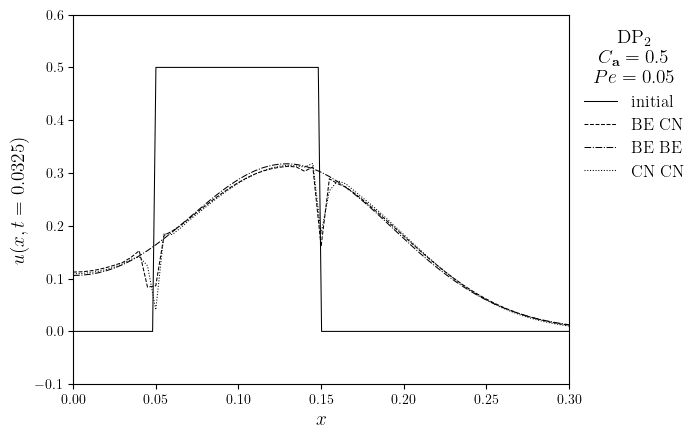

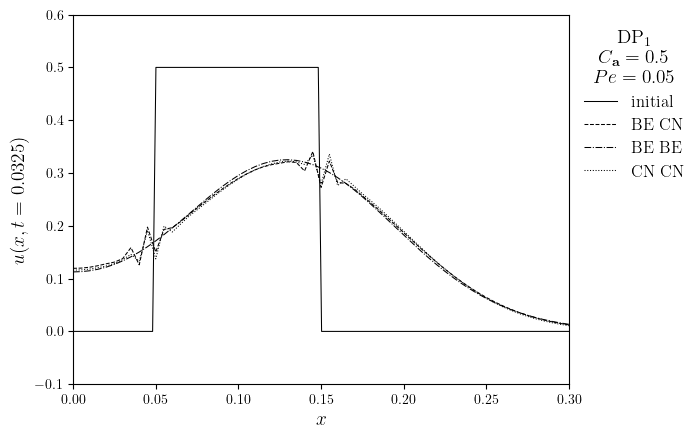

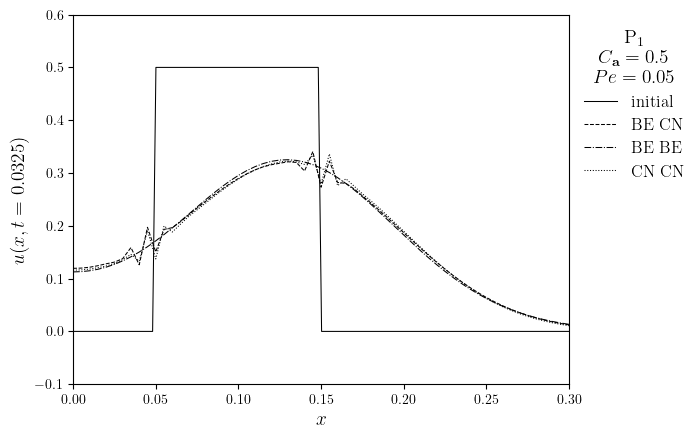

In [ ]:
x = np.linspace(0, Lx, num=500)
t_target = int(0.1 * n_stop) * dt
for elem in elem_opts:
    fam, deg = elem
    legend_title = f'{fam}$_{deg}$\n $C_{{\\mathbf{{a}}}}={courant}$\n $Pe={Pe:.2f}$'
    lines = [(x, tophat(x, mu, x0, l))]
    legend_labels = ['initial']
    for D_adv_diff in D_adv_diff_opts:
        D_adv, D_diff = D_adv_diff
        u = simulations[elem][D_adv_diff]['u']
        time_index = as_index(u.time_series, t_target)
        lines.append(u.series[time_index])
        legend_labels.append(f'{D_adv} {D_diff}')
    fig, ax = plot_line(lines, legend_labels, legend_title, x_label='$x$', y_label=f'$u(x,t={t_target})$')
    ax.set_xlim(0.0, x0 + 2 * l)
    ax.set_ylim(-0.1, mu + 0.1)
    save_figure(f'Pe={Pe:.2f}_C={courant}_{fam}{deg}', thumbnail=(elem == ('DP', 1)))(fig)